<h1 align='center'>Trend Analysis by Release Year  </h1>

### Import Dataset and Verify Column + Data Type

In [1]:
import pandas as pd
df = pd.read_csv(f'E:\internship\Auspify\cleaned_netflix_dataset.csv')

In [2]:
print(df["release_year"].head())
print(f"Data type: {df['release_year'].dtype}")
print(f"Missing values: {df['release_year'].isna().sum()}")

0    2020
1    2021
2    2021
3    2021
4    1993
Name: release_year, dtype: int64
Data type: int64
Missing values: 0


### Organize content by release year

In [3]:
year_data = df.sort_values("release_year")

print(year_data[["title", "release_year"]].head(10))

                                                 title  release_year
421                  Pioneers: First Women Filmmakers*          1925
5698                                    Prelude to War          1942
6037                              The Battle of Midway          1942
6510                   WWII: Report from the Aleutians          1943
6422     Undercover: How to Operate Behind Enemy Lines          1943
6491                Why We Fight: The Battle of Russia          1943
6230                                 The Negro Soldier          1944
6218  The Memphis Belle: A Story of a\nFlying Fortress          1944
6406                                  Tunisian Victory          1944
6874               Five Came Back: The Reference Films          1945


### Calculate Yearly Content Release

In [4]:
yearly_content = (df["release_year"].value_counts().sort_index().reset_index())

yearly_content.columns = ["Release Year", "Content Count"]
print(yearly_content)

    Release Year  Content Count
0           1925              1
1           1942              2
2           1943              3
3           1944              3
4           1945              4
..           ...            ...
69          2017           1030
70          2018           1146
71          2019           1030
72          2020            953
73          2021            592

[74 rows x 2 columns]


### Growth and Decline Trends

In [5]:
# Calculate year-over-year change
yearly_content["Yearly Change"] = (yearly_content["Content Count"].diff())

# Calculate year-over-year percentage change
yearly_content["Growth %"] = (yearly_content["Content Count"].pct_change() * 100)

print(yearly_content.tail(15))

    Release Year  Content Count  Yearly Change   Growth %
59          2007             88           -8.0  -8.333333
60          2008            135           47.0  53.409091
61          2009            152           17.0  12.592593
62          2010            192           40.0  26.315789
63          2011            185           -7.0  -3.645833
64          2012            236           51.0  27.567568
65          2013            286           50.0  21.186441
66          2014            352           66.0  23.076923
67          2015            555          203.0  57.670455
68          2016            901          346.0  62.342342
69          2017           1030          129.0  14.317425
70          2018           1146          116.0  11.262136
71          2019           1030         -116.0 -10.122164
72          2020            953          -77.0  -7.475728
73          2021            592         -361.0 -37.880378


In [6]:
# Identify the year with the highest number of releases
peak_year = yearly_content.loc[yearly_content["Content Count"].idxmax()]

print(f"Peak year: {int(peak_year['Release Year'])} "
    f"with {int(peak_year['Content Count'])} titles")

Peak year: 2018 with 1146 titles


#### Key Findings

- Content releases increased strongly from 2012 to 2018, with the highest growth occurring in 2015 and 2016.
- Content releases reached their peak in 2018, with 1,146 titles.
- Releases declined by 10.12% in 2019 and by 7.48% in 2020.
- The count for 2021 dropped by 37.88%, but this should not be treated as a full-year decline because 2021 may represent only partial-year data.

### Trend Visuals

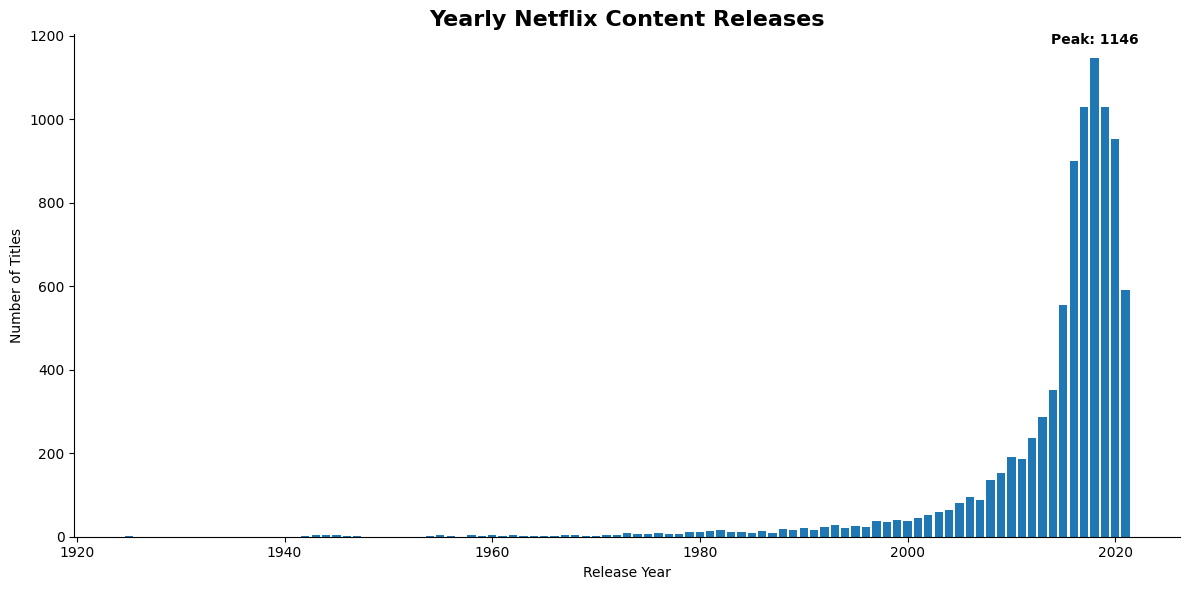

In [8]:
import matplotlib.pyplot as plt
# Create bar chart
plt.figure(figsize=(12, 6))
bars = plt.bar(yearly_content["Release Year"],yearly_content["Content Count"])

plt.title("Yearly Netflix Content Releases",fontsize=16, fontweight="bold")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

# Label the peak year
peak_index = yearly_content["Content Count"].idxmax()
peak_bar = bars[peak_index]

plt.annotate(
    f"Peak: {int(peak_bar.get_height())}",
    xy=(peak_bar.get_x() + peak_bar.get_width() / 2,
        peak_bar.get_height()),
    xytext=(0, 10),textcoords="offset points",ha="center",fontweight="bold")

# Remove unnecessary borders
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### Key Findings

- Netflix content releases showed a strong upward trend from 2012 to 2018.
- The number of releases increased sharply in 2015 and 2016, indicating a period of rapid content expansion.
- Content releases reached their highest level in 2018, with 1,146 titles.
- After 2018, releases declined to 1,030 titles in 2019 and 953 in 2020.
- The 2021 count is lower at 592 titles, but this may reflect incomplete data for the year and should not be treated as a full-year decline.
- Overall, the data shows strong content expansion followed by a decline after the 2018 peak.